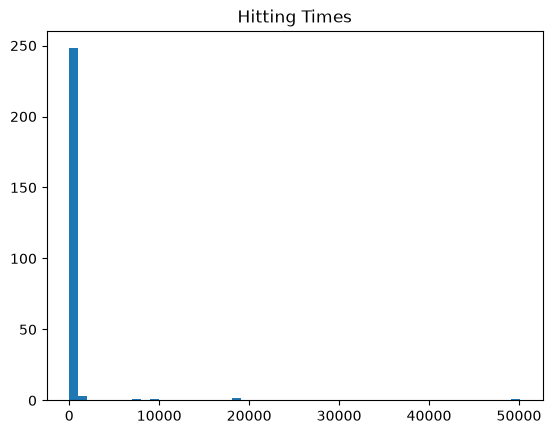

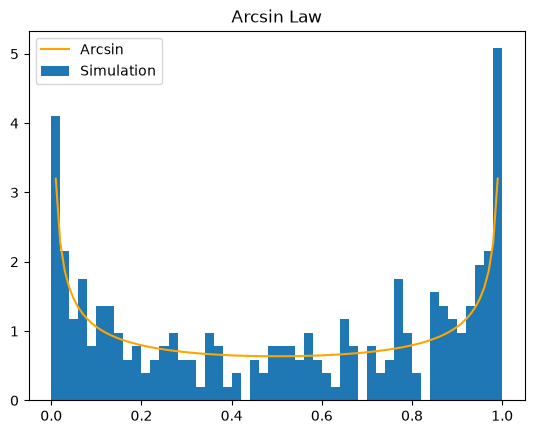

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

class RandomWalk:
    def __init__(self, X, P):
        self.init = 0
        self.X = X
        self.P = P
        self.T = None
        self.N = None
        self.paths = None
    
    def generate_path(self, T, N=1):
        self.T = T
        self.N = N
        self.paths = np.random.choice(a=self.X, p=self.P, size=(N, T), replace=True).cumsum(axis=1) + self.init
        return self
    
    def hitting_times(self, threshold=0):
        hitting_times = []
        for i in range(self.N):
            hits = np.where(self.paths[i] == threshold)[0]
            if len(hits) > 0:
                hitting_times.append(hits[0].item() + 1)
        return hitting_times
    
    def plot_hitting_times(self, threshold=0):
        plt.hist(self.hitting_times(threshold=threshold), bins=50)
        # plt.yscale('log')
        plt.title("Hitting Times")
        plt.show()
        plt.close()

    def above_times(self, threshold):
        return np.where(self.paths > threshold, 1, 0).sum(axis=1)

    def below_times(self, threshold):
        return np.where(self.paths < threshold, 1, 0).sum(axis=1)

    def plot_arcsin_law(self, greater=True):
        if greater:
            times = self.above_times(threshold=self.init)
        else:
            times = self.below_times(threshold=self.init)
        
        normalized_times = times / self.T
        
        x = np.linspace(0.01, 0.99, 100)
        y = 1 / (np.pi * np.sqrt(x * (1 - x)))
        plt.plot(x, y, color="orange", label="Arcsin")

        plt.hist(normalized_times, bins=50, density=True, label="Simulation")
        
        plt.title("Arcsin Law")
        plt.legend()
        plt.show()
        plt.close()

class SimpleSymmetricRandomWalk(RandomWalk):
    def __init__(self):
        super().__init__(X=[1, -1], P=[1/2, 1/2])

T = 2 ** 16
N = 2 ** 8

RW = SimpleSymmetricRandomWalk().generate_path(T=T, N=N)

RW.plot_hitting_times(threshold=0)
RW.plot_arcsin_law()
